In [1]:
import matplotlib as plt
import pandas as pd
import pylahman

In [2]:
df_people = pylahman.People()

In [70]:
df_matchups = pd.read_csv('../matchups_v1.0.csv')
df_matchups['date'] = pd.to_datetime(df_matchups['gid'].str[3:11], format="%Y%m%d")

## Plotted Career ELO

Get the player's retrosheet id

In [25]:
def get_retro_id(first, last):
    return df_people.loc[
        (df_people['nameFirst'].str.lower() == first) &
        (df_people['nameLast'].str.lower() == last)
        ][['retroID']].values[0][0]

## Barry Bonds

date
1986    1581.317170
1987    1605.819979
1988    1681.139986
1989    1636.307153
1990    1685.561185
Name: batter_rating_post, dtype: float64


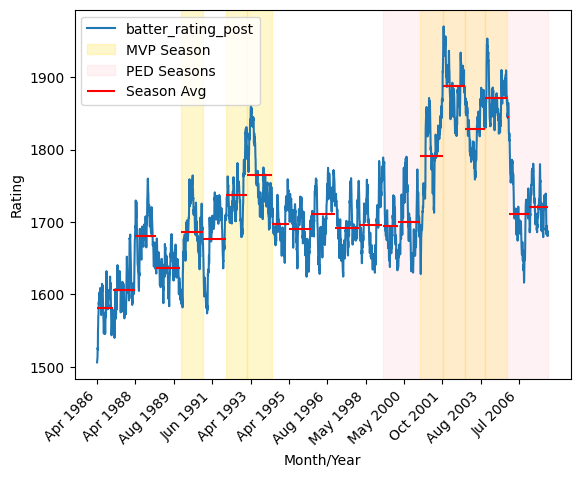

In [ ]:
# Get Retrosheet ID
retro_id = get_retro_id('barry', 'bonds')

# Get the plot first
df_temp = df_matchups.loc[df_matchups['batter'] == retro_id][['date', 'batter_rating_post']].groupby('date').max()
ax = df_temp.reset_index(drop=True).plot()

# Fix the date-indexed x-axis (otherwise it gives huge gaps between seasons)
ticks = range(0, len(df_temp), 250)
ax.set_xticks(ticks)
ax.set_xticklabels(
    [df_temp.index[i].strftime('%b %Y') for i in ticks],
    rotation=45, ha='right'
)

# Set axis titles
ax.set_xlabel("Month/Year")
ax.set_ylabel("Rating")
# TODO: Try to plot where he got hurt, highlight the peak

mvp_years = [1990, 1992, 1993, 2001, 2002, 2003, 2004]

for i, year in enumerate(mvp_years):
    x_start = df_temp.index.get_indexer([pd.Timestamp(f'{year}-02-01')], method='nearest')[0]
    x_end = df_temp.index.get_indexer([pd.Timestamp(f'{year}-11-30')], method='nearest')[0]
    
    ax.axvspan(x_start, x_end, alpha=0.2, color='gold',
               label='MVP Season' if i == 0 else '')

x_start = df_temp.index.get_indexer([pd.Timestamp(f'1999-02-01')], method='nearest')[0]
x_end = df_temp.index.get_indexer([pd.Timestamp(f'2007-11-30')], method='nearest')[0]
ax.axvspan(x_start, x_end, alpha=0.2, color='pink',
            label='PED Seasons')

season_averages = df_temp.groupby(df_temp.index.year)['batter_rating_post'].mean()
for i, year in enumerate(df_temp.index.year.unique()):
    x_start = df_temp.index.get_indexer([pd.Timestamp(f'{year}-02-01')], method='nearest')[0]
    x_end = df_temp.index.get_indexer([pd.Timestamp(f'{year}-11-01')], method='nearest')[0]

    ax.hlines(y=season_averages[year], xmin=x_start, xmax=x_end, color='red', linewidth=1.5, label='Season Avg' if i == 0 else '')

ax.legend()

## Joey Votto

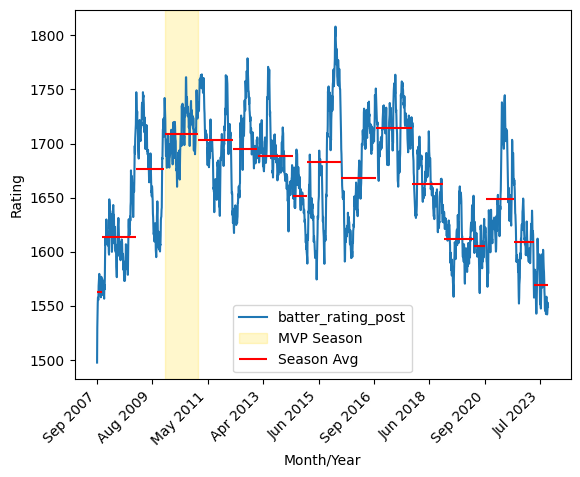

In [88]:
# Get Retrosheet ID
retro_id = get_retro_id('joey', 'votto')

# Get the plot first
df_temp = df_matchups.loc[df_matchups['batter'] == retro_id][['date', 'batter_rating_post']].groupby('date').max()

ax = df_temp.reset_index(drop=True).plot()

# Fix the date-indexed x-axis (otherwise it gives huge gaps between seasons)
ticks = range(0, len(df_temp), 250)
ax.set_xticks(ticks)
ax.set_xticklabels(
    [df_temp.index[i].strftime('%b %Y') for i in ticks],
    rotation=45, ha='right'
)

# Set axis titles
ax.set_xlabel("Month/Year")
ax.set_ylabel("Rating")
# TODO: Try to plot where he got hurt, highlight the peak

mvp_years = [2010]

for i, year in enumerate(mvp_years):
    x_start = df_temp.index.get_indexer([pd.Timestamp(f'{year}-02-01')], method='nearest')[0]
    x_end = df_temp.index.get_indexer([pd.Timestamp(f'{year}-11-01')], method='nearest')[0]
    
    ax.axvspan(x_start, x_end, alpha=0.2, color='gold',
               label='MVP Season' if i == 0 else '')

season_averages = df_temp.groupby(df_temp.index.year)['batter_rating_post'].mean()
for i, year in enumerate(df_temp.index.year.unique()):
    x_start = df_temp.index.get_indexer([pd.Timestamp(f'{year}-02-01')], method='nearest')[0]
    x_end = df_temp.index.get_indexer([pd.Timestamp(f'{year}-11-01')], method='nearest')[0]

    ax.hlines(y=season_averages[year], xmin=x_start, xmax=x_end, color='red', linewidth=1.5, label='Season Avg' if i == 0 else '')

ax.legend()

## Aaron Judge

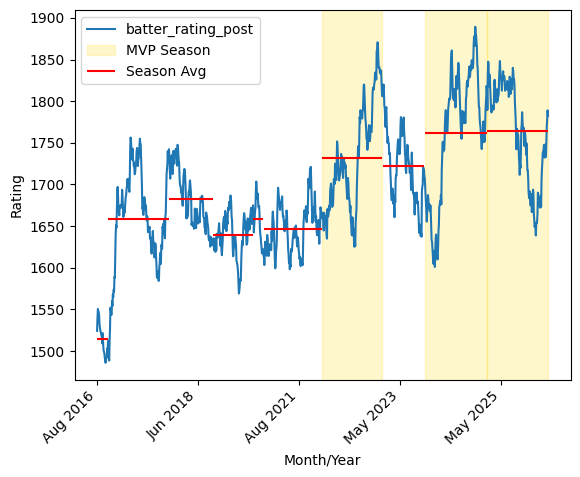

In [89]:
# Get Retrosheet ID
retro_id = get_retro_id('aaron', 'judge')

# Get the plot first
df_temp = df_matchups.loc[df_matchups['batter'] == retro_id][['date', 'batter_rating_post']].groupby('date').max()

ax = df_temp.reset_index(drop=True).plot()

# Fix the date-indexed x-axis (otherwise it gives huge gaps between seasons)
ticks = range(0, len(df_temp), 250)
ax.set_xticks(ticks)
ax.set_xticklabels(
    [df_temp.index[i].strftime('%b %Y') for i in ticks],
    rotation=45, ha='right'
)

# Set axis titles
ax.set_xlabel("Month/Year")
ax.set_ylabel("Rating")
# TODO: Try to plot where he got hurt, highlight the peak

mvp_years = [2022, 2024, 2025]

for i, year in enumerate(mvp_years):
    x_start = df_temp.index.get_indexer([pd.Timestamp(f'{year}-02-01')], method='nearest')[0]
    x_end = df_temp.index.get_indexer([pd.Timestamp(f'{year}-11-01')], method='nearest')[0]
    
    ax.axvspan(x_start, x_end, alpha=0.2, color='gold',
               label='MVP Season' if i == 0 else '')

season_averages = df_temp.groupby(df_temp.index.year)['batter_rating_post'].mean()
for i, year in enumerate(df_temp.index.year.unique()):
    x_start = df_temp.index.get_indexer([pd.Timestamp(f'{year}-02-01')], method='nearest')[0]
    x_end = df_temp.index.get_indexer([pd.Timestamp(f'{year}-11-01')], method='nearest')[0]

    ax.hlines(y=season_averages[year], xmin=x_start, xmax=x_end, color='red', linewidth=1.5, label='Season Avg' if i == 0 else '')

ax.legend()

In [26]:
df_matchups.groupby('batter')['batter_rating_pre'].max().sort_values(ascending=False).head(15)

batter
bondb001    1970.009
maysw101    1910.566
judga001    1889.428
willt103    1885.137
mantm101    1874.058
howaf102    1868.188
yastc101    1867.152
cashn101    1860.217
musis101    1857.465
yelic001    1855.422
robif103    1851.356
mccow101    1847.683
howar001    1846.029
hartj102    1843.899
sotoj001    1843.076
Name: batter_rating_pre, dtype: float64

In [71]:
df_matchups.groupby('batter')['batter_rating_pre'].max().sort_values(ascending=False).head(15)

batter
bondb001    1970.009
maysw101    1910.566
judga001    1889.428
willt103    1885.137
mantm101    1874.058
howaf102    1868.188
yastc101    1867.152
cashn101    1860.217
musis101    1857.465
yelic001    1855.422
robif103    1851.356
mccow101    1847.683
howar001    1846.029
hartj102    1843.899
sotoj001    1843.076
Name: batter_rating_pre, dtype: float64